 # Dataset Analysis

Comprehensive characterisation of all benchmark datasets used in the
Calibrated Agency experiments. Results feed directly into **Chapter 4.2
(Benchmarks and Tasks)** of the thesis.

## Datasets
**Final thesis benchmarks (three, reported):**

| Benchmark | Paper | Task type | Tool | Auto-download |
|---|---|---|---|---|
| **GSM8K** | Cobbe et al. (2021) | Multi-step arithmetic | Calculator (MCP) | ✅ HuggingFace |
| **AgentBench-DB** | Liu et al. (2024) | Interactive SQL | SQLite (MCP) | ⚙️ `setup_agentbench.sh` |
| **HotpotQA** | Yang et al. (2018) | Multi-hop open-domain QA | search / lookup / finish | ✅ HuggingFace |

**Considered during experimentation, excluded from the final thesis scope** (sections below
kept for reference — see `legacy/README.md`):

| Benchmark | Paper | Task type | Tool | Auto-download |
|---|---|---|---|---|
| **AgentBench-OS** | Liu et al. (2024) | Interactive Linux bash | Bash (Docker) | ⚙️ `setup_agentbench.sh` |
| **ToolBench-G1** | Qin et al. (2023) | Single-tool REST API chaining | REST (mock server) | ⚙️ `legacy/setup_toolbench.sh` |
| **ToolBench-G2** | Qin et al. (2023) | Intra-category multi-tool | REST (mock server) | ⚙️ `legacy/setup_toolbench.sh` |

**GSM8K and HotpotQA are downloaded automatically from HuggingFace when you run the setup cell below.**  
AgentBench and ToolBench sections show graceful placeholders if their repos are not yet cloned.

In [25]:

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
from importlib.util import module_from_spec, spec_from_file_location
from types import SimpleNamespace
import runpy

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# DATA_DIR is defined in the setup cell above; fall back for standalone execution
if 'DATA_DIR' not in dir():
    DATA_DIR = Path('../data')

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

def load_stats(benchmark):
    p = DATA_DIR / benchmark / 'stats.json'
    return json.loads(p.read_text()) if p.exists() else None


In [26]:

# ---------------------------------------------------------------------------
# Auto-setup: download & prepare GSM8K from HuggingFace if not yet done.
# AgentBench / ToolBench are optional — their sections show placeholders
# if the repos haven't been cloned yet.
# ---------------------------------------------------------------------------
import subprocess
import sys
from pathlib import Path

REPO_ROOT   = Path('..').resolve()
SCRIPTS_DIR = REPO_ROOT / 'scripts'
DATA_DIR    = REPO_ROOT / 'data'

# Add BOTH the repo root (for config.py) and scripts/ (for prepare_datasets.py)
# to sys.path so local imports shadow any same-named conda packages.
for p in [str(REPO_ROOT), str(SCRIPTS_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# --- GSM8K (auto-downloadable from HuggingFace) ---
gsm8k_ready = (DATA_DIR / 'gsm8k' / 'test.jsonl').exists()

if not gsm8k_ready:
    # Import here, not at the top of the notebook: it needs SCRIPTS_DIR on sys.path,
    # which this cell sets up above, and only runs when data is actually missing.
    print('GSM8K data not found — downloading from HuggingFace (openai/gsm8k)...')
    print('This requires the `datasets` package: pip install datasets')
    print()
    from prepare_datasets import prepare_gsm8k, build_summary
    gsm8k_stats = prepare_gsm8k(force=False)
    build_summary({'gsm8k': gsm8k_stats})
    print('\n✓ GSM8K ready.')
else:
    print('✓ GSM8K data already present.')

# Summarise what's available
available = [d.name for d in DATA_DIR.iterdir() if d.is_dir()] if DATA_DIR.exists() else []
missing   = [b for b in ['agentbench_os', 'agentbench_db', 'toolbench_g1', 'toolbench_g2']
             if b not in available]

print(f'Available datasets : {available}')
if missing:
    print(f'Not yet prepared   : {missing}')
    print('  → AgentBench: bash scripts/setup_agentbench.sh  then  python scripts/prepare_datasets.py --only agentbench_os agentbench_db')
    print('  → ToolBench : bash legacy/setup_toolbench.sh   then  python scripts/prepare_datasets.py --only toolbench_g1 toolbench_g2')


✓ GSM8K data already present.
Available datasets : ['AgentBench', 'gsm8k', 'hotpotqa']
Not yet prepared   : ['agentbench_os', 'agentbench_db', 'toolbench_g1', 'toolbench_g2']
  → AgentBench: bash scripts/setup_agentbench.sh  then  python scripts/prepare_datasets.py --only agentbench_os agentbench_db
  → ToolBench : bash legacy/setup_toolbench.sh   then  python scripts/prepare_datasets.py --only toolbench_g1 toolbench_g2


---
## 1  GSM8K
Grade-school multi-step arithmetic problems. Each solution requires a chain
of reasoning steps and arithmetic calculations — the prototypical setting for
a tool-augmented calculator agent.

In [27]:
gsm_stats = load_stats('gsm8k')
gsm_test  = load_jsonl(DATA_DIR / 'gsm8k' / 'test.jsonl')
gsm_train = load_jsonl(DATA_DIR / 'gsm8k' / 'train.jsonl')

print(f"GSM8K  |  Train: {len(gsm_train):,}   Test: {len(gsm_test):,}")
print()

# Print summary statistics table
for split_name, split_stats in gsm_stats['splits'].items():
    print(f"--- {split_name.upper()} ---")
    for k, v in split_stats.items():
        if v is not None:
            print(f"  {k:<35} {v:.3f}" if isinstance(v, float) else f"  {k:<35} {v}")

GSM8K  |  Train: 7,473   Test: 1,319

--- TRAIN ---
  n_examples                          7473
  answer_numeric_count                7473
  difficulty_counts                   {'Easy': 1961, 'Medium': 3808, 'Hard': 1704}
  answer_min                          -47.000
  answer_max                          192000000.000
  answer_median                       44.000
  answer_p25                          14.000
  answer_p75                          180.000
  steps_mean                          3.576
  steps_std                           1.421
  steps_min                           2
  steps_max                           9
  steps_median                        3.000
  calculations_mean                   3.174
  calculations_std                    1.400
  calculations_median                 3.000
  question_len_mean                   45.093
  question_len_std                    17.481
--- TEST ---
  n_examples                          1319
  answer_numeric_count                1319
  difficulty

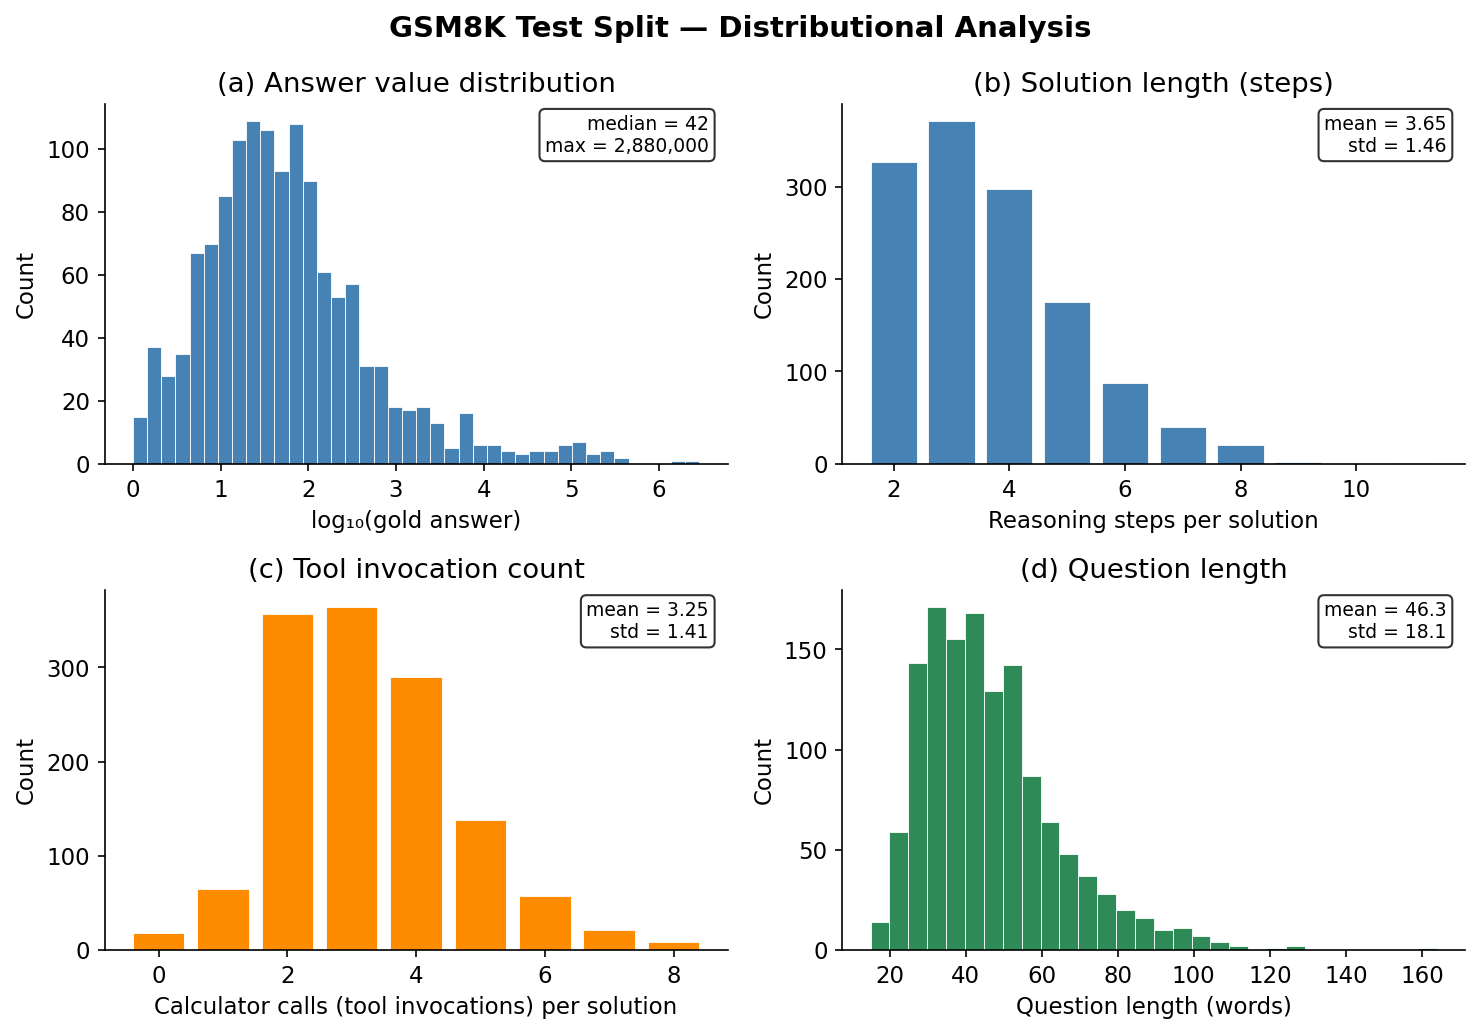

Saved → results/figures/data/gsm8k_dataset_analysis.png


In [50]:
# Extract key arrays from test split
gold_answers = [float(r['gold_answer']) for r in gsm_test if r['gold_answer']]
step_counts  = [r['metadata']['n_steps'] for r in gsm_test]
calc_counts  = [r['metadata']['n_calculations'] for r in gsm_test]
q_lengths    = [r['metadata']['question_len'] for r in gsm_test]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('GSM8K Test Split — Distributional Analysis', fontsize=14, fontweight='bold')

# (a) Answer value distribution (log scale)
ax = axes[0, 0]
pos_answers = [a for a in gold_answers if a > 0]
ax.hist(np.log10(pos_answers), bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('log₁₀(gold answer)')
ax.set_ylabel('Count')
ax.set_title('(a) Answer value distribution')
ax.text(0.97, 0.97, f'median = {np.median(gold_answers):.0f}\nmax = {max(gold_answers):,.0f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# (b) Number of reasoning steps per solution
ax = axes[0, 1]
step_vals, step_cnts = np.unique(step_counts, return_counts=True)
ax.bar(step_vals, step_cnts, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Reasoning steps per solution')
ax.set_ylabel('Count')
ax.set_title('(b) Solution length (steps)')
ax.text(0.97, 0.97, f'mean = {np.mean(step_counts):.2f}\nstd = {np.std(step_counts):.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# (c) Number of calculator calls per solution
ax = axes[1, 0]
calc_vals, calc_cnts = np.unique(calc_counts, return_counts=True)
ax.bar(calc_vals, calc_cnts, color='darkorange', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Calculator calls (tool invocations) per solution')
ax.set_ylabel('Count')
ax.set_title('(c) Tool invocation count')
ax.text(0.97, 0.97, f'mean = {np.mean(calc_counts):.2f}\nstd = {np.std(calc_counts):.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# (d) Question length distribution
ax = axes[1, 1]
ax.hist(q_lengths, bins=30, color='seagreen', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Question length (words)')
ax.set_ylabel('Count')
ax.set_title('(d) Question length')
ax.text(0.97, 0.97, f'mean = {np.mean(q_lengths):.1f}\nstd = {np.std(q_lengths):.1f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
Path('../results').mkdir(exist_ok=True)
plt.savefig('../results/figures/data/gsm8k_dataset_analysis.png', bbox_inches='tight')
plt.show()
print('Saved → results/figures/data/gsm8k_dataset_analysis.png')

In [29]:
# Example problems for thesis (show 3 short + 3 long)
by_steps = sorted(gsm_test, key=lambda r: r['metadata']['n_steps'])

print('=== SHORTEST PROBLEMS (2 steps) ===')
for r in by_steps[:3]:
    print(f"[{r['task_id']}] Steps={r['metadata']['n_steps']}, Calcs={r['metadata']['n_calculations']}")
    print(f"  Q: {r['instruction'][:120]}...")
    print(f"  A: {r['gold_answer']}")
    print()

print('=== LONGEST PROBLEMS (max steps) ===')
for r in by_steps[-3:]:
    print(f"[{r['task_id']}] Steps={r['metadata']['n_steps']}, Calcs={r['metadata']['n_calculations']}")
    print(f"  Q: {r['instruction'][:120]}...")
    print(f"  A: {r['gold_answer']}")
    print()

=== SHORTEST PROBLEMS (2 steps) ===
[gsm8k_test_0] Steps=2, Calcs=2
  Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every da...
  A: 18

[gsm8k_test_1] Steps=2, Calcs=2
  Q: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?...
  A: 3

[gsm8k_test_3] Steps=2, Calcs=2
  Q: James decides to run 3 sprints 3 times a week.  He runs 60 meters each sprint.  How many total meters does he run a week...
  A: 540

=== LONGEST PROBLEMS (max steps) ===
[gsm8k_test_500] Steps=9, Calcs=5
  Q: Together Lily, David, and Bodhi collected 43 insects. Lily found 7 more than David. David found half of what Bodhi found...
  A: 16

[gsm8k_test_950] Steps=9, Calcs=2
  Q: Bahati, Azibo, and Dinar each contributed to their team's 45 points. Bahati scored the most points and it was 20 more th...
  A: 5

[gsm8k_test_687] Steps=11, Calcs=5
  Q: There is one set of twins and one set of triplets

In [30]:
# LaTeX-ready summary table for thesis Chapter 4.2
test_s = gsm_stats['splits']['test']
train_s = gsm_stats['splits']['train']

print('--- GSM8K LATEX TABLE CONTENT ---')
print(f"N train        & {train_s['n_examples']:,} \\\\")
print(f"N test         & {test_s['n_examples']:,} \\\\")
print(f"Steps/sol (mean ± std) & {test_s['steps_mean']:.2f} ± {test_s['steps_std']:.2f} \\\\")
print(f"Steps range    & [{test_s['steps_min']}, {test_s['steps_max']}] \\\\")
print(f"Tool calls/sol (mean ± std) & {test_s['calculations_mean']:.2f} ± {test_s['calculations_std']:.2f} \\\\")
print(f"Question len (words, mean ± std) & {test_s['question_len_mean']:.1f} ± {test_s['question_len_std']:.1f} \\\\")
print(f"Gold answer range & [{test_s['answer_min']:.0f}, {test_s['answer_max']:,.0f}] \\\\")
print(f"Gold answer median & {test_s['answer_median']:.0f} \\\\")

--- GSM8K LATEX TABLE CONTENT ---
N train        & 7,473 \\
N test         & 1,319 \\
Steps/sol (mean ± std) & 3.65 ± 1.46 \\
Steps range    & [2, 11] \\
Tool calls/sol (mean ± std) & 3.25 ± 1.41 \\
Question len (words, mean ± std) & 46.3 ± 18.1 \\
Gold answer range & [-10, 2,880,000] \\
Gold answer median & 42 \\


---
## 2  AgentBench (OS + DB)

**Only AgentBench-DB is a final thesis benchmark. AgentBench-OS was evaluated during
experimentation but dropped from the final scope — kept here for reference; see
`legacy/README.md`.**

AgentBench provides interactive environments where agents execute multi-turn bash
commands (OS) or SQL statements (DB) to solve real-world tasks. Unlike GSM8K's
self-contained arithmetic problems, AgentBench requires:

- **Stateful execution**: Commands modify system state; agent must track context
- **Multi-turn reasoning**: Tasks typically require 3-20 actions to complete
- **Complex tools**: Bash has unlimited action space; SQL requires schema understanding
- **Non-deterministic outcomes**: Command results depend on environment state

**Dataset organization:**
- **OS Interaction**: Interactive Linux/Unix bash command execution (26 dev tasks)
- **DB Interaction**: SQL query generation and execution (60 dev tasks)

The tasks are more complex than GSM8K: shorter instructions (~20 words vs. ~46),
but require deep environment understanding and multi-step action planning.

In [31]:
# Load AgentBench dataset files
agentbench_root = Path('../AgentBench')

# --- OS tasks (dev.json, 26 tasks — unchanged) ---
os_path = agentbench_root / 'data' / 'os_interaction' / 'data' / 'dev.json'
with open(os_path) as f:
    os_data = json.load(f)
print(f"OS Interaction (dev.json): {len(os_data)} tasks")

# --- DB tasks: dev.jsonl (60) + standard.jsonl (300) = 360 total ---
# Mirrors the experiment setup in agentbench_agent.py
db_dir = agentbench_root / 'data' / 'dbbench'
db_dev      = [json.loads(l) for l in open(db_dir / 'dev.jsonl')      if l.strip()]
db_standard = [json.loads(l) for l in open(db_dir / 'standard.jsonl') if l.strip()]
db_data = db_dev + db_standard
print(f"DB Interaction (dev.jsonl + standard.jsonl): {len(db_data)} tasks "
      f"({len(db_dev)} dev + {len(db_standard)} standard)")

# --- Task type classification (SELECT / INSERT / UPDATE / DELETE) ---
def classify_db_task(record):
    lbl = (record.get('label') or [''])[0].strip().upper()
    for op in ('INSERT', 'UPDATE', 'DELETE'):
        if lbl.startswith(op):
            return op
    return 'SELECT'

db_task_types  = [classify_db_task(d) for d in db_data]
db_type_counts = Counter(db_task_types)

# --- Instruction text & lengths ---
os_instructions = [t.get('description', t.get('instruction', '')) for t in os_data]
db_instructions = [t.get('description', '') for t in db_data]
os_lens = [len(s.split()) for s in os_instructions]
db_lens = [len(s.split()) for s in db_instructions]

print(f"\n=== AGENTBENCH — OS INTERACTION (Bash) ===")
print(f"N tasks           : {len(os_data)}")
print(f"Instr. len (words): mean={np.mean(os_lens):.1f}, std={np.std(os_lens):.1f}")
print(f"Instr. range      : [{min(os_lens)}, {max(os_lens)}] words")

print(f"\n=== AGENTBENCH — DB INTERACTION (SQL) ===")
print(f"N tasks           : {len(db_data)} (dev={len(db_dev)}, standard={len(db_standard)})")
print(f"Task types        : {dict(db_type_counts)}")
print(f"Instr. len (words): mean={np.mean(db_lens):.1f}, std={np.std(db_lens):.1f}")
print(f"Instr. range      : [{min(db_lens)}, {max(db_lens)}] words")

# DB table structure analysis
table_cols, table_rows = [], []
for t in db_data:
    if 'table' in t and isinstance(t['table'], dict):
        table_info = t['table'].get('table_info', {})
        if 'columns' in table_info:
            table_cols.append(len(table_info['columns']))
        if 'rows' in table_info:
            table_rows.append(len(table_info['rows']))

if table_cols:
    print(f"Avg table columns : {np.mean(table_cols):.1f} +/- {np.std(table_cols):.1f}")
    print(f"Avg table rows    : {np.mean(table_rows):.1f} +/- {np.std(table_rows):.1f}")
    print(f"Column range      : [{min(table_cols)}, {max(table_cols)}]")
    print(f"Row range         : [{min(table_rows)}, {max(table_rows)}]")

OS Interaction (dev.json): 26 tasks
DB Interaction (dev.jsonl + standard.jsonl): 360 tasks (60 dev + 300 standard)

=== AGENTBENCH — OS INTERACTION (Bash) ===
N tasks           : 26
Instr. len (words): mean=19.2, std=17.4
Instr. range      : [5, 71] words

=== AGENTBENCH — DB INTERACTION (SQL) ===
N tasks           : 360 (dev=60, standard=300)
Task types        : {'SELECT': 120, 'INSERT': 120, 'UPDATE': 120}
Instr. len (words): mean=22.0, std=12.8
Instr. range      : [4, 74] words
Avg table columns : 5.7 +/- 1.7
Avg table rows    : 25.5 +/- 10.9
Column range      : [3, 17]
Row range         : [7, 105]


C:\Users\Chris\AppData\Local\Temp\ipykernel_86088\1118930417.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels_present, patch_artist=True, widths=0.5)


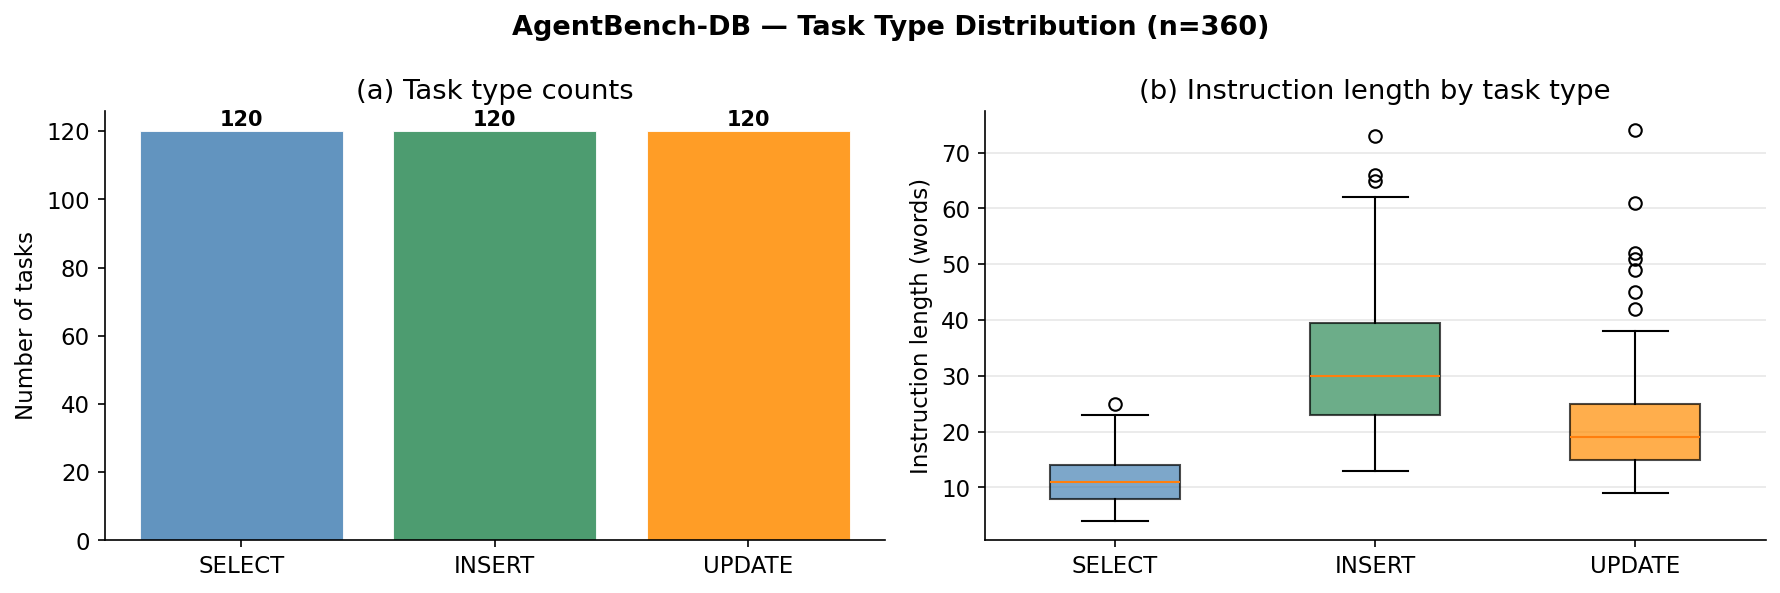


Task Type      Count    Share   Mean len (words)
--------------------------------------------------
SELECT           120   33.3%               11.6
INSERT           120   33.3%               32.3
UPDATE           120   33.3%               21.9


In [32]:
# DB task type breakdown — bar chart + table
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'AgentBench-DB — Task Type Distribution (n={len(db_data)})', fontsize=13, fontweight='bold')

# (a) Bar chart
ax = axes[0]
type_order  = ['SELECT', 'INSERT', 'UPDATE']
type_colors = {'SELECT': 'steelblue', 'INSERT': 'seagreen', 'UPDATE': 'darkorange'}
counts = [db_type_counts.get(t, 0) for t in type_order]
bars = ax.bar(type_order, counts,
              color=[type_colors[t] for t in type_order],
              edgecolor='white', linewidth=0.5, alpha=0.85)
ax.set_ylabel('Number of tasks')
ax.set_title('(a) Task type counts')
for bar, cnt in zip(bars, counts):
    if cnt > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=10)

# (b) Instruction length by task type
ax = axes[1]
type_lens = {t: [] for t in type_order}
for instr, ttype in zip(db_instructions, db_task_types):
    type_lens[ttype].append(len(instr.split()))
data_to_plot   = [type_lens[t] for t in type_order if type_lens[t]]
labels_present = [t for t in type_order if type_lens[t]]
bp = ax.boxplot(data_to_plot, labels=labels_present, patch_artist=True, widths=0.5)
for patch, lbl in zip(bp['boxes'], labels_present):
    patch.set_facecolor(type_colors[lbl])
    patch.set_alpha(0.7)
ax.set_ylabel('Instruction length (words)')
ax.set_title('(b) Instruction length by task type')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
Path('../results/figures/data').mkdir(parents=True, exist_ok=True)
plt.savefig('../results/figures/data/agentbench_db_task_types.png', bbox_inches='tight', dpi=150)
plt.show()

# Summary table
print(f"\n{'Task Type':<12} {'Count':>7} {'Share':>8} {'Mean len (words)':>18}")
print('-' * 50)
for t in type_order:
    cnt      = db_type_counts.get(t, 0)
    lens     = type_lens[t]
    mean_len = f'{np.mean(lens):.1f}' if lens else '—'
    print(f"{t:<12} {cnt:>7} {cnt/len(db_data):>7.1%} {mean_len:>18}")

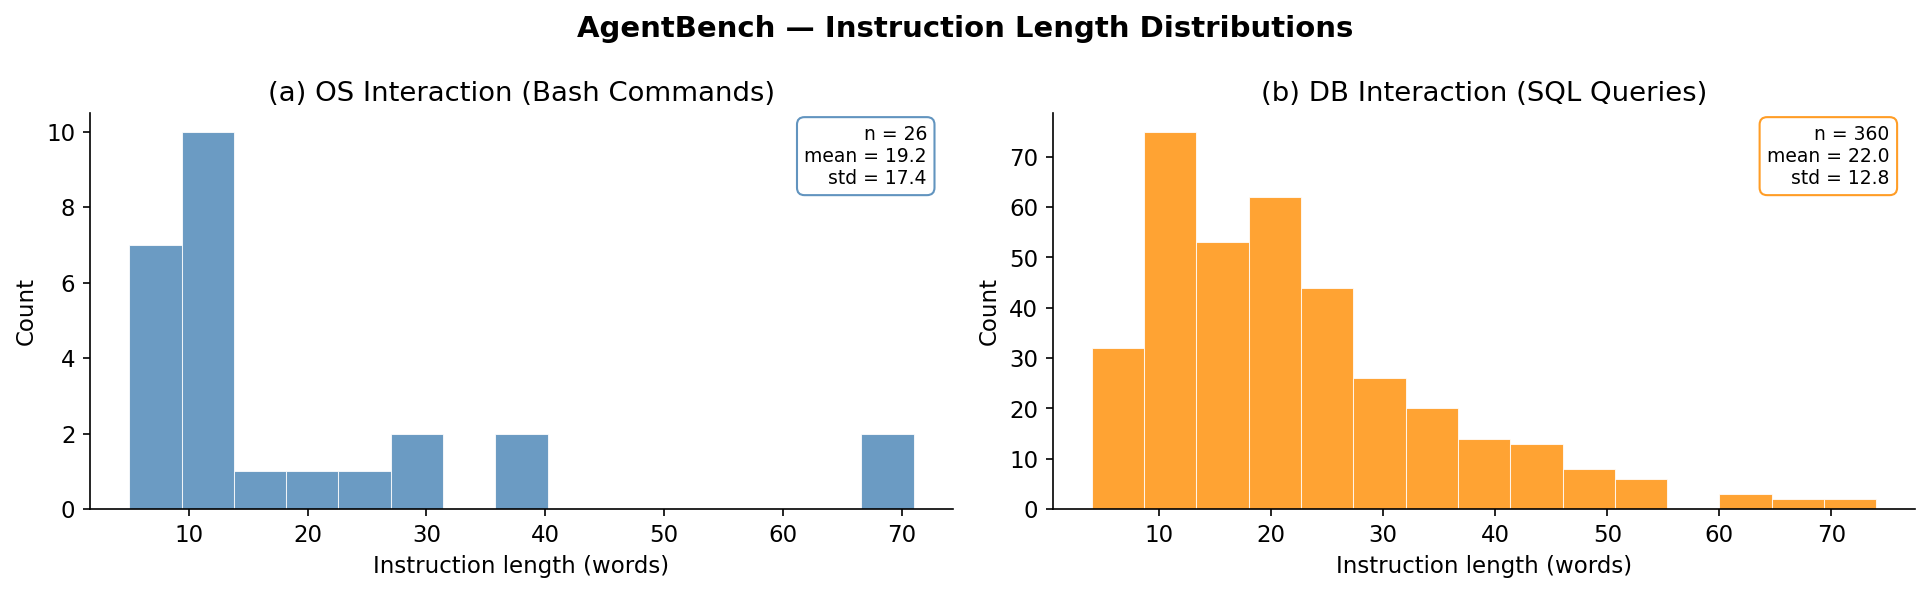

In [33]:
# Instruction length distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('AgentBench — Instruction Length Distributions', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(os_lens, bins=15, color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Instruction length (words)')
ax.set_ylabel('Count')
ax.set_title('(a) OS Interaction (Bash Commands)')
ax.text(0.97, 0.97, f'n = {len(os_lens)}\nmean = {np.mean(os_lens):.1f}\nstd = {np.std(os_lens):.1f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='steelblue', linewidth=1))

ax = axes[1]
ax.hist(db_lens, bins=15, color='darkorange', edgecolor='white', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Instruction length (words)')
ax.set_ylabel('Count')
ax.set_title('(b) DB Interaction (SQL Queries)')
ax.text(0.97, 0.97, f'n = {len(db_lens)}\nmean = {np.mean(db_lens):.1f}\nstd = {np.std(db_lens):.1f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='darkorange', linewidth=1))

plt.tight_layout()
Path('../results/figures/data').mkdir(parents=True, exist_ok=True)
plt.savefig('../results/figures/data/agentbench_dataset_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

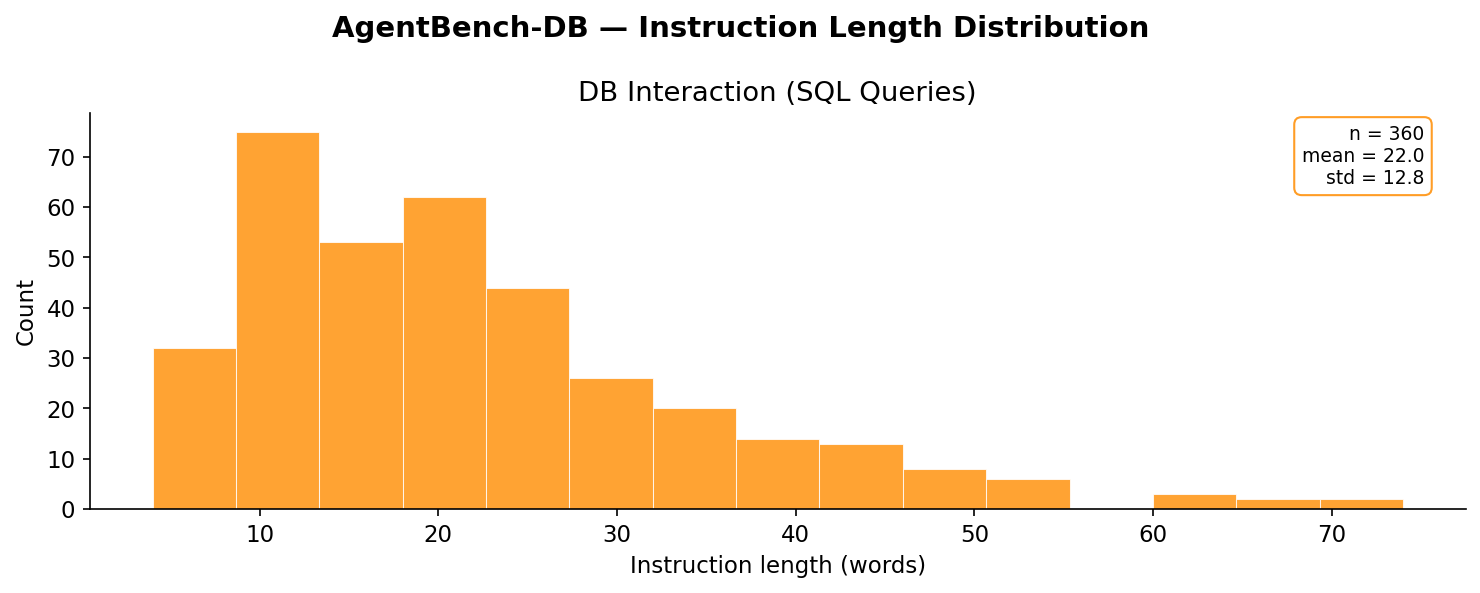

In [34]:
# Instruction length distribution — DB only
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
fig.suptitle('AgentBench-DB — Instruction Length Distribution', fontsize=14, fontweight='bold')

ax.hist(db_lens, bins=15, color='darkorange', edgecolor='white', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Instruction length (words)')
ax.set_ylabel('Count')
ax.set_title('DB Interaction (SQL Queries)')
ax.text(0.97, 0.97, f'n = {len(db_lens)}\nmean = {np.mean(db_lens):.1f}\nstd = {np.std(db_lens):.1f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='darkorange', linewidth=1))

plt.tight_layout()
Path('../results/figures/data').mkdir(parents=True, exist_ok=True)
plt.savefig('../results/figures/data/agentbench_db_dataset_analysis_DB.png', bbox_inches='tight', dpi=150)
plt.show()

In [35]:
# Representative examples
print("="*70)
print("OS INTERACTION — REPRESENTATIVE EXAMPLES")
print("="*70)

os_by_len = sorted(enumerate(os_instructions), key=lambda x: len(x[1].split()))

print("\n[SHORT] Simplest tasks (5-10 words):")
for idx, task in os_by_len[:3]:
    print(f"  [{idx:2d}] {task}")

print("\n[MEDIUM] Moderate complexity (15-25 words):")
mid_idx = len(os_by_len) // 2
for idx, task in os_by_len[mid_idx:mid_idx+3]:
    print(f"  [{idx:2d}] {task}")

print("\n[LONG] Complex tasks (50+ words):")
for idx, task in os_by_len[-3:]:
    print(f"  [{idx:2d}] {task}")

print("\n" + "="*70)
print("DB INTERACTION — REPRESENTATIVE EXAMPLES")
print("="*70)

db_by_len = sorted(enumerate(db_instructions), key=lambda x: len(x[1].split()))

print("\n[SHORT] Simple queries (7-15 words):")
for idx, task in db_by_len[:3]:
    print(f"  [{idx:2d}] {task}")

print("\n[MEDIUM] Moderate queries (20-30 words):")
mid_idx = len(db_by_len) // 2
for idx, task in db_by_len[mid_idx:mid_idx+3]:
    print(f"  [{idx:2d}] {task}")

print("\n[LONG] Complex queries (50+ words):")
for idx, task in db_by_len[-3:]:
    print(f"  [{idx:2d}] {task}")

OS INTERACTION — REPRESENTATIVE EXAMPLES

[SHORT] Simplest tasks (5-10 words):
  [17] Find out count of users.
  [18] Find out count of users.
  [13] What's the count of my CPUs?

[MEDIUM] Moderate complexity (15-25 words):
  [19] Find out count of users who belong to at least 2 groups.
  [20] Find out count of users who belong to at least 4 groups.
  [ 9] How many empty files are there in /home and all of its content?

[LONG] Complex tasks (50+ words):
  [ 4] There's a program that writes 'succeed' into /root/log periodically. I only know the interval is 1 second, 2 seconds, or 3 seconds. Please find out the interval. Answer me only the integer number of seconds. (e.g. 1, 2, or 3)
  [ 5] I would like to implement the following function: entering the "calc" command will enable the calculation of an expression. The expression can include addition, subtraction, multiplication, division, and parentheses. If the absolute error between the calculated answer and the expected answer is less t

C:\Users\Chris\AppData\Local\Temp\ipykernel_86088\2646524953.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['GSM8K', 'AgentBench-OS', 'AgentBench-DB'],


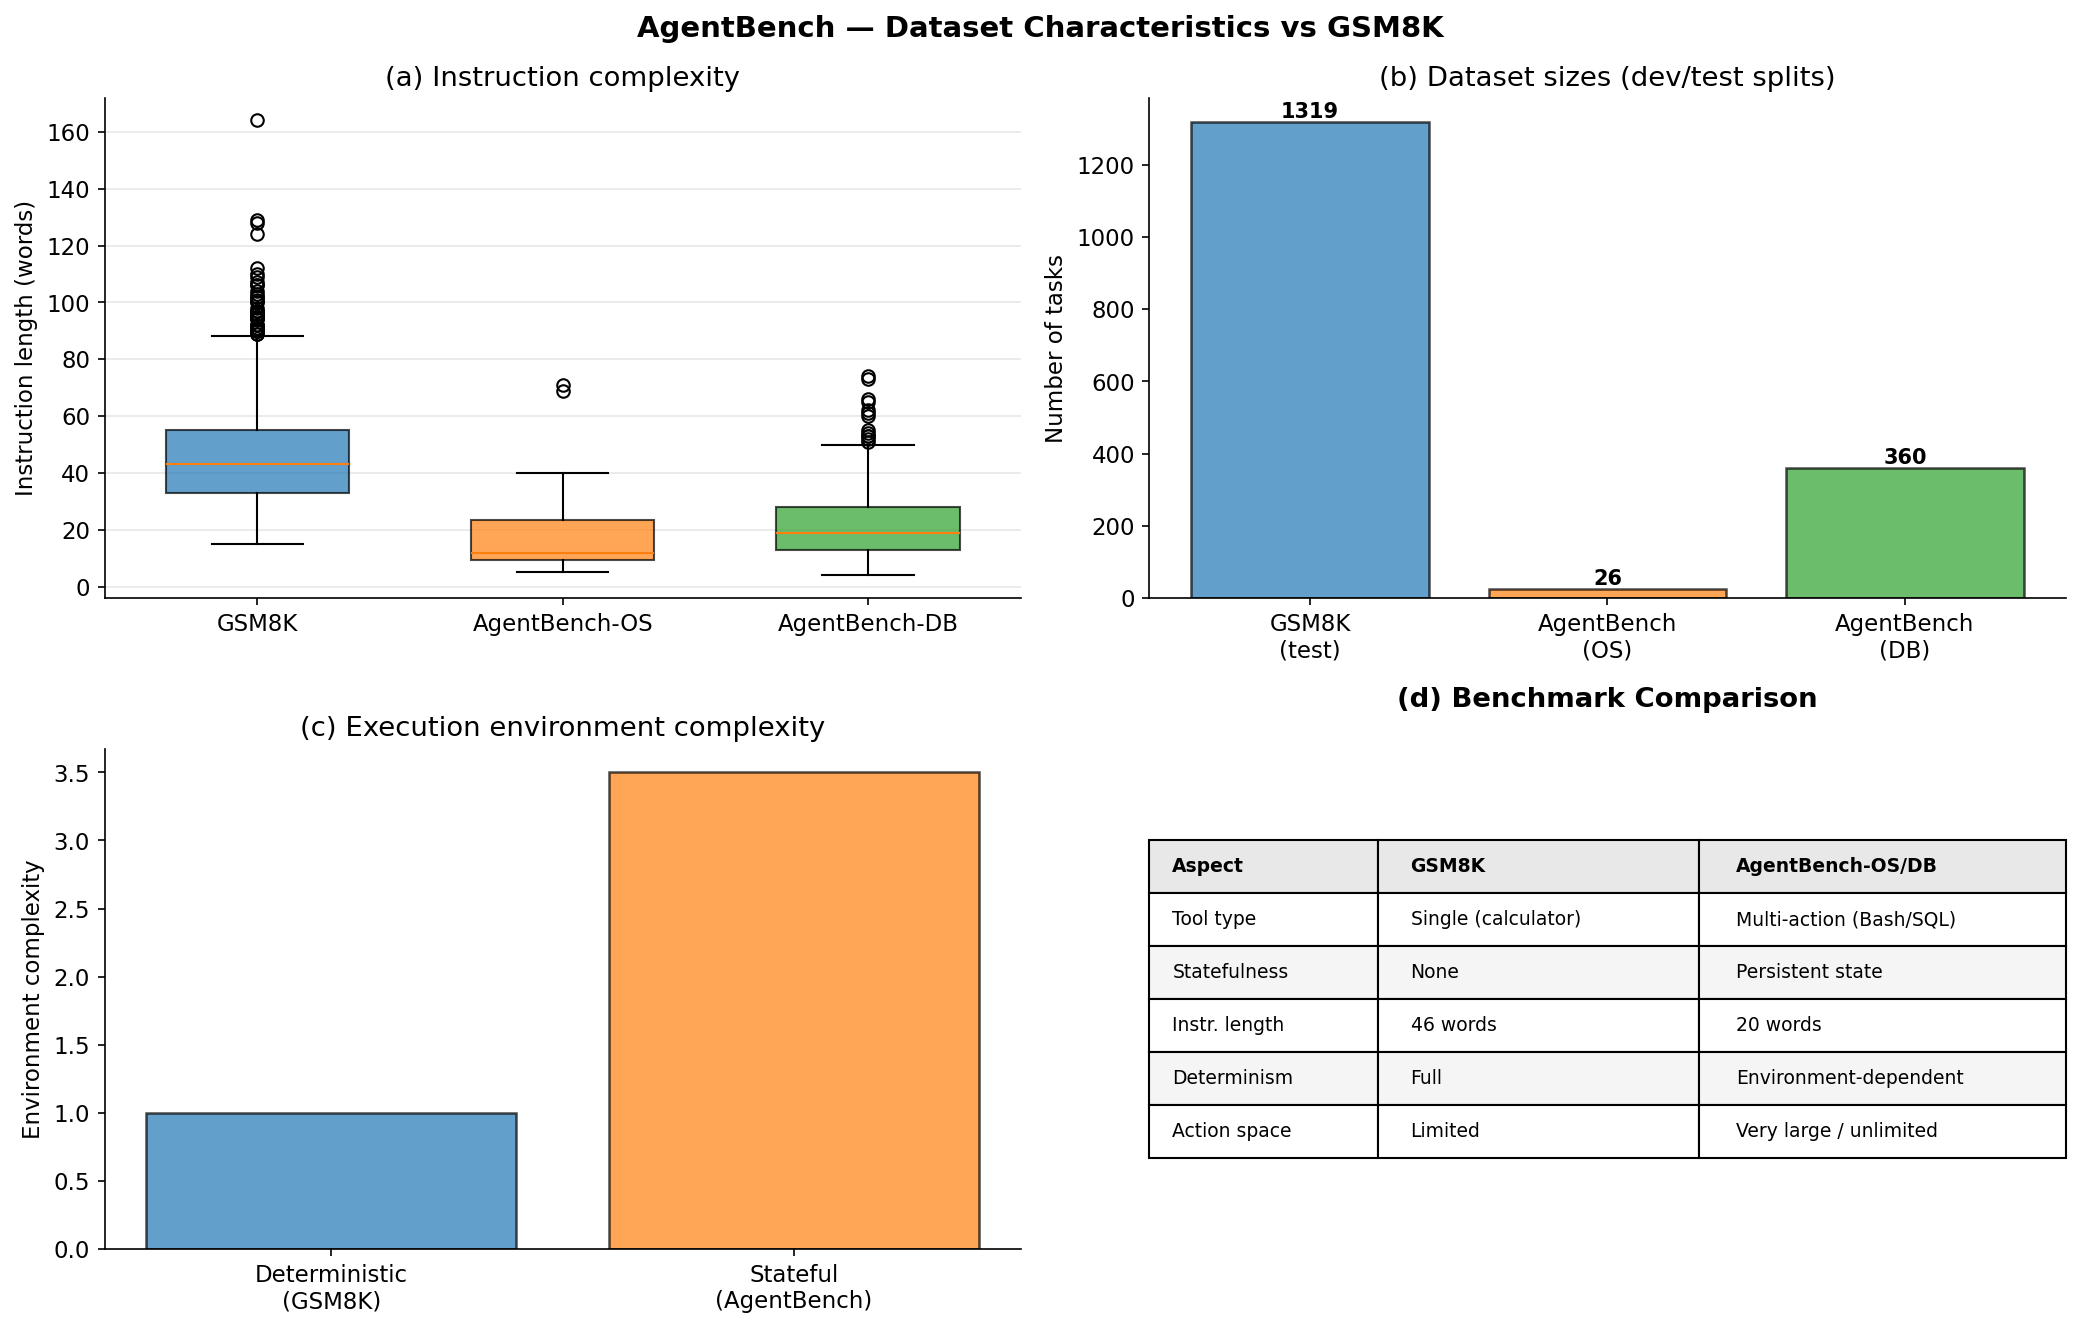

In [36]:
# Comparative analysis: AgentBench vs GSM8K
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('AgentBench — Dataset Characteristics vs GSM8K', fontsize=14, fontweight='bold')

# (a) Instruction length comparison
ax = axes[0, 0]
gsm8k_lens = [len(r['instruction'].split()) for r in gsm_test]
data_to_plot = [gsm8k_lens, os_lens, db_lens]
bp = ax.boxplot(data_to_plot, labels=['GSM8K', 'AgentBench-OS', 'AgentBench-DB'],
                 patch_artist=True, widths=0.6)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Instruction length (words)')
ax.set_title('(a) Instruction complexity')
ax.grid(axis='y', alpha=0.3)

# (b) Dataset size
ax = axes[0, 1]
benchmarks = ['GSM8K\n(test)', 'AgentBench\n(OS)', 'AgentBench\n(DB)']
sizes = [len(gsm_test), len(os_data), len(db_data)]
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar(benchmarks, sizes, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.2)
ax.set_ylabel('Number of tasks')
ax.set_title('(b) Dataset sizes (dev/test splits)')
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(size)}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# (c) Complexity characteristics
ax = axes[1, 0]
categories = ['Deterministic\n(GSM8K)', 'Stateful\n(AgentBench)']
complexity = [1.0, 3.5]
ax.bar(categories, complexity, color=['#1f77b4', '#ff7f0e'], alpha=0.7, edgecolor='black', linewidth=1.2)
ax.set_ylabel('Environment complexity')
ax.set_title('(c) Execution environment complexity')

# (d) Benchmark differences table
ax = axes[1, 1]
ax.axis('off')

table_data = [
    ['Aspect', 'GSM8K', 'AgentBench-OS/DB'],
    ['Tool type', 'Single (calculator)', 'Multi-action (Bash/SQL)'],
    ['Statefulness', 'None', 'Persistent state'],
    ['Instr. length', '46 words', '20 words'],
    ['Determinism', 'Full', 'Environment-dependent'],
    ['Action space', 'Limited', 'Very large / unlimited'],
]

table = ax.table(cellText=table_data, cellLoc='left', loc='center', colWidths=[0.25, 0.35, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

for i in range(3):
    table[(0, i)].set_facecolor('#E8E8E8')
    table[(0, i)].set_text_props(weight='bold')

for i in range(1, len(table_data)):
    color = '#F5F5F5' if i % 2 == 0 else 'white'
    for j in range(3):
        table[(i, j)].set_facecolor(color)

ax.set_title('(d) Benchmark Comparison', loc='center', pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/data/agentbench_vs_gsm8k.png', bbox_inches='tight', dpi=150)
plt.show()

In [37]:
# LaTeX-ready summary for thesis
print("\n" + "="*70)
print("LATEX TABLE CONTENT — AGENTBENCH")
print("="*70)

print(f"\nOS Interaction & {len(os_data):3d} & {np.mean(os_lens):5.1f} \\\\")
print(f"DB Interaction & {len(db_data):3d} & {np.mean(db_lens):5.1f} \\\\")

print(f"\nOS instr. range & [{min(os_lens)}, {max(os_lens)}] words \\\\")
print(f"DB instr. range & [{min(db_lens)}, {max(db_lens)}] words \\\\")

if table_cols:
    print(f"\nDB avg columns & {np.mean(table_cols):.1f} +/- {np.std(table_cols):.1f} \\\\")
    print(f"DB avg rows & {np.mean(table_rows):.1f} +/- {np.std(table_rows):.1f} \\\\")

print(f"\nDB task type breakdown:")
for t in ['SELECT', 'INSERT', 'UPDATE', 'DELETE']:
    cnt = db_type_counts.get(t, 0)
    print(f"  {t} & {cnt} & {cnt/len(db_data):.1%} \\\\")

# Cross-benchmark comparison
gsm8k_lens = [len(r['instruction'].split()) for r in gsm_test]
print(f"\nGSM8K (test) & {len(gsm_test)} & {np.mean(gsm8k_lens):.1f} words \\\\")
print(f"AgentBench-OS & {len(os_data)} & {np.mean(os_lens):.1f} words \\\\")
print(f"AgentBench-DB & {len(db_data)} & {np.mean(db_lens):.1f} words \\\\")


LATEX TABLE CONTENT — AGENTBENCH

OS Interaction &  26 &  19.2 \\
DB Interaction & 360 &  22.0 \\

OS instr. range & [5, 71] words \\
DB instr. range & [4, 74] words \\

DB avg columns & 5.7 +/- 1.7 \\
DB avg rows & 25.5 +/- 10.9 \\

DB task type breakdown:
  SELECT & 120 & 33.3% \\
  INSERT & 120 & 33.3% \\
  UPDATE & 120 & 33.3% \\
  DELETE & 0 & 0.0% \\

GSM8K (test) & 1319 & 46.3 words \\
AgentBench-OS & 26 & 19.2 words \\
AgentBench-DB & 360 & 22.0 words \\


---
## 3  HotpotQA

HotpotQA (Yang et al., 2018) is a multi-hop question-answering benchmark. Each question
requires retrieving and reasoning across **exactly two** supporting paragraphs from a pool
of 10 candidates (2 gold + 8 distractors), then synthesising a free-text answer.

Unlike GSM8K (closed-form arithmetic) and AgentBench (stateful execution), HotpotQA tests
**open-domain retrieval and multi-hop synthesis** — the agent must iteratively query a
retriever to locate both supporting paragraphs, then compose an answer that may require
chaining or comparing facts across them.

**Question types:**
- **Bridge** (~80 %): *sequential two-hop* — identify entity A from the question, retrieve a
  property of A, use that property to find entity B, then answer about B
- **Comparison** (~20 %): *parallel lookup* — retrieve the same attribute for two entities A
  and B, then compare (e.g., "Which is older, X or Y?")

**Difficulty** — the train split mixes easy / medium / hard levels; the **validation split is
100 % hard** by dataset design. Since all experiments use the validation set, every one of the
500 experimental examples is a hard multi-hop question.

**Experiment setup:** validation split (first 500), 50/50 calib–test, `max_steps=12`,
`max_tokens=100`, ReAct agent with `search` / `lookup` / `finish` tools,
word-overlap ContextSearcher (2 × title weight, 1 × body weight).

In [38]:
hpqa_train_path = DATA_DIR / 'hotpotqa' / 'train.jsonl'
hpqa_val_path   = DATA_DIR / 'hotpotqa' / 'validation.jsonl'

if not hpqa_train_path.exists():
    print('HotpotQA not found — run: python scripts/prepare_datasets.py --only hotpotqa')
    hpqa_train = hpqa_val = []
else:
    hpqa_train = load_jsonl(hpqa_train_path)
    hpqa_val   = load_jsonl(hpqa_val_path)
    print(f"HotpotQA  |  Train: {len(hpqa_train):,}   Validation: {len(hpqa_val):,}")
    print()

    def answer_type(ans):
        a = ans.strip().lower()
        if a in ('yes', 'no'):
            return 'yes/no'
        toks = a.split()
        if len(toks) == 1:
            return 'single-word entity'
        if len(toks) <= 4:
            return 'short phrase (≤4 words)'
        return 'long phrase (>4 words)'

    for split_name, split_data in [('TRAIN', hpqa_train), ('VALIDATION', hpqa_val)]:
        n       = len(split_data)
        types   = Counter(r['metadata']['type']  for r in split_data)
        levels  = Counter(r['metadata']['level'] for r in split_data)
        q_lens  = [r['metadata']['question_len'] for r in split_data]
        a_lens  = [r['metadata']['answer_len']   for r in split_data]
        a_types = Counter(answer_type(r['gold_answer']) for r in split_data)
        print(f"--- {split_name} (n={n:,}) ---")
        print(f"  Types  : bridge={types['bridge']:,} ({types['bridge']/n:.1%})   "
              f"comparison={types['comparison']:,} ({types['comparison']/n:.1%})")
        print(f"  Levels : {dict(sorted(levels.items()))}")
        print(f"  Q len  : mean={np.mean(q_lens):.1f} ± {np.std(q_lens):.1f},  "
              f"range=[{min(q_lens)}, {max(q_lens)}]  (words)")
        print(f"  A len  : mean={np.mean(a_lens):.1f} ± {np.std(a_lens):.1f},  "
              f"range=[{min(a_lens)}, {max(a_lens)}]  (words)")
        print(f"  Ans    : {dict(a_types)}")
        print()

HotpotQA  |  Train: 90,447   Validation: 7,405

--- TRAIN (n=90,447) ---
  Types  : bridge=72,991 (80.7%)   comparison=17,456 (19.3%)
  Levels : {'easy': 17972, 'hard': 15661, 'medium': 56814}
  Q len  : mean=17.8 ± 9.5,  range=[3, 108]  (words)
  A len  : mean=2.2 ± 1.8,  range=[1, 89]  (words)
  Ans    : {'short phrase (≤4 words)': 53719, 'single-word entity': 26464, 'long phrase (>4 words)': 4783, 'yes/no': 5481}

--- VALIDATION (n=7,405) ---
  Types  : bridge=5,918 (79.9%)   comparison=1,487 (20.1%)
  Levels : {'hard': 7405}
  Q len  : mean=15.7 ± 5.5,  range=[6, 46]  (words)
  A len  : mean=2.5 ± 1.8,  range=[1, 29]  (words)
  Ans    : {'yes/no': 458, 'short phrase (≤4 words)': 4399, 'single-word entity': 1897, 'long phrase (>4 words)': 651}



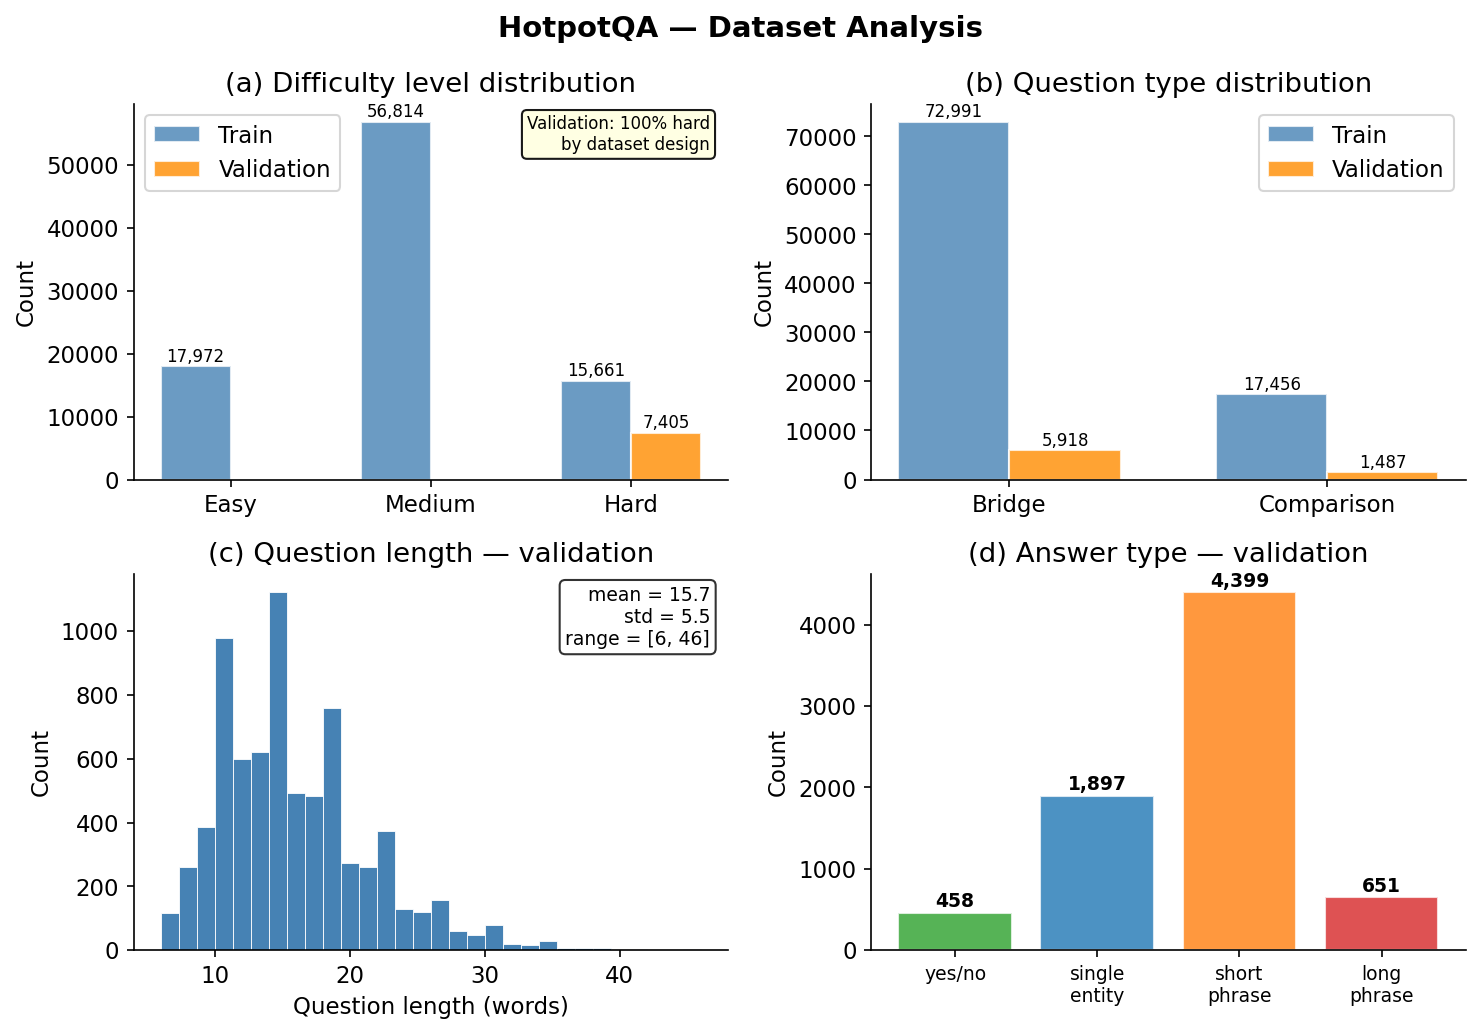

Saved → results/figures/data/hotpotqa_dataset_analysis.png


In [49]:
# HotpotQA — 2×2 distributional analysis
if not hpqa_val:
    print('Skip: HotpotQA data not available.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle('HotpotQA — Dataset Analysis', fontsize=14, fontweight='bold')

    # (a) Difficulty level — train vs validation
    ax = axes[0, 0]
    train_levels = Counter(r['metadata']['level'] for r in hpqa_train)
    val_levels   = Counter(r['metadata']['level'] for r in hpqa_val)
    level_order  = ['easy', 'medium', 'hard']
    x, w = np.arange(len(level_order)), 0.35
    train_cnts = [train_levels.get(l, 0) for l in level_order]
    val_cnts   = [val_levels.get(l, 0)   for l in level_order]
    b1 = ax.bar(x - w/2, train_cnts, w, label='Train',      color='steelblue',  alpha=0.8, edgecolor='white')
    b2 = ax.bar(x + w/2, val_cnts,   w, label='Validation', color='darkorange', alpha=0.8, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels([l.capitalize() for l in level_order])
    ax.set_ylabel('Count')
    ax.set_title('(a) Difficulty level distribution')
    ax.legend()
    for bar, cnt in [(b, c) for b, c in zip(list(b1)+list(b2), train_cnts+val_cnts) if c > 0]:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                f'{cnt:,}', ha='center', va='bottom', fontsize=8)
    ax.text(0.97, 0.97, 'Validation: 100% hard\nby dataset design',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

    # (b) Question type — train vs validation
    ax = axes[0, 1]
    train_types = Counter(r['metadata']['type'] for r in hpqa_train)
    val_types   = Counter(r['metadata']['type'] for r in hpqa_val)
    type_order  = ['bridge', 'comparison']
    x2          = np.arange(len(type_order))
    train_t = [train_types[t] for t in type_order]
    val_t   = [val_types[t]   for t in type_order]
    b3 = ax.bar(x2 - w/2, train_t, w, label='Train',      color='steelblue',  alpha=0.8, edgecolor='white')
    b4 = ax.bar(x2 + w/2, val_t,   w, label='Validation', color='darkorange', alpha=0.8, edgecolor='white')
    ax.set_xticks(x2); ax.set_xticklabels([t.capitalize() for t in type_order])
    ax.set_ylabel('Count')
    ax.set_title('(b) Question type distribution')
    ax.legend()
    for bar, cnt in [(b, c) for b, c in zip(list(b3)+list(b4), train_t+val_t) if c > 0]:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                f'{cnt:,}', ha='center', va='bottom', fontsize=8)

    # (c) Question length — validation
    ax = axes[1, 0]
    val_q_lens = [r['metadata']['question_len'] for r in hpqa_val]
    ax.hist(val_q_lens, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Question length (words)')
    ax.set_ylabel('Count')
    ax.set_title('(c) Question length — validation')
    ax.text(0.97, 0.97,
            f'mean = {np.mean(val_q_lens):.1f}\nstd = {np.std(val_q_lens):.1f}\n'
            f'range = [{min(val_q_lens)}, {max(val_q_lens)}]',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # (d) Answer type — validation
    ax = axes[1, 1]
    val_a_types  = Counter(answer_type(r['gold_answer']) for r in hpqa_val)
    atype_order  = ['yes/no', 'single-word entity', 'short phrase (≤4 words)', 'long phrase (>4 words)']
    atype_labels = ['yes/no', 'single\nentity', 'short\nphrase', 'long\nphrase']
    atype_colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
    atype_cnts   = [val_a_types.get(t, 0) for t in atype_order]
    bars = ax.bar(range(len(atype_order)), atype_cnts, color=atype_colors, alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(atype_order))); ax.set_xticklabels(atype_labels, fontsize=9)
    ax.set_ylabel('Count')
    ax.set_title('(d) Answer type — validation')
    for bar, cnt in zip(bars, atype_cnts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f'{cnt:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    Path('../results/figures/data').mkdir(parents=True, exist_ok=True)
    plt.savefig('../results/figures/data/hotpotqa_dataset_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved → results/figures/data/hotpotqa_dataset_analysis.png')

In [40]:
# Validation split — detailed breakdown by question type + context structure
if hpqa_val:
    val_bridge     = [r for r in hpqa_val if r['metadata']['type'] == 'bridge']
    val_comparison = [r for r in hpqa_val if r['metadata']['type'] == 'comparison']

    print("=== VALIDATION — TYPE BREAKDOWN ===\n")
    for label, subset in [('Bridge', val_bridge), ('Comparison', val_comparison)]:
        n       = len(subset)
        q_lens  = [r['metadata']['question_len'] for r in subset]
        a_lens  = [r['metadata']['answer_len']   for r in subset]
        a_types = Counter(answer_type(r['gold_answer']) for r in subset)
        print(f"{label} (n={n:,},  {n/len(hpqa_val):.1%}):")
        print(f"  Q len    : mean={np.mean(q_lens):.1f} ± {np.std(q_lens):.1f}  "
              f"range=[{min(q_lens)}, {max(q_lens)}]")
        print(f"  A len    : mean={np.mean(a_lens):.1f} ± {np.std(a_lens):.1f}  "
              f"range=[{min(a_lens)}, {max(a_lens)}]")
        print(f"  Ans types: {dict(a_types)}")
        print()

    # Context / supporting facts structure
    sf_sents    = [len(r['metadata']['supporting_facts'])   for r in hpqa_val]
    all_sents   = [len(p['sentences'])
                   for r in hpqa_val for p in r['metadata']['context']]
    n_pars      = Counter(r['metadata']['n_paragraphs']             for r in hpqa_val)
    sf_titles   = Counter(len(r['metadata']['supporting_fact_titles']) for r in hpqa_val)

    print("=== CONTEXT STRUCTURE (always fixed) ===\n")
    print(f"Paragraphs / question      : {dict(n_pars)}  (always 10 = 2 gold + 8 distractors)")
    print(f"Supporting fact titles     : {dict(sf_titles)}  (always exactly 2)")
    print(f"Supporting fact sentences  : mean={np.mean(sf_sents):.2f} ± {np.std(sf_sents):.2f},  "
          f"range=[{min(sf_sents)}, {max(sf_sents)}]")
    print(f"Sentences / paragraph      : mean={np.mean(all_sents):.2f} ± {np.std(all_sents):.2f},  "
          f"range=[{min(all_sents)}, {max(all_sents)}]")

    # Experiment subset
    exp_subset = hpqa_val[:500]
    exp_types  = Counter(r['metadata']['type'] for r in exp_subset)
    print(f"\n=== EXPERIMENT SUBSET (n=500, first 500 of validation) ===")
    print(f"Bridge     : {exp_types['bridge']} ({exp_types['bridge']/5:.1f}%)")
    print(f"Comparison : {exp_types['comparison']} ({exp_types['comparison']/5:.1f}%)")
    print(f"All level='hard'")
    print(f"Calib / test split: 250 / 250 (50 % / 50 %)")

=== VALIDATION — TYPE BREAKDOWN ===

Bridge (n=5,918,  79.9%):
  Q len    : mean=16.8 ± 5.5  range=[6, 46]
  A len    : mean=2.6 ± 1.8  range=[1, 29]
  Ans types: {'short phrase (≤4 words)': 3747, 'single-word entity': 1605, 'long phrase (>4 words)': 566}

Comparison (n=1,487,  20.1%):
  Q len    : mean=11.5 ± 3.1  range=[6, 27]
  A len    : mean=2.1 ± 1.8  range=[1, 18]
  Ans types: {'yes/no': 458, 'short phrase (≤4 words)': 652, 'single-word entity': 292, 'long phrase (>4 words)': 85}

=== CONTEXT STRUCTURE (always fixed) ===

Paragraphs / question      : {10: 7345, 2: 21, 5: 6, 8: 4, 4: 9, 6: 8, 9: 3, 7: 2, 3: 7}  (always 10 = 2 gold + 8 distractors)
Supporting fact titles     : {2: 7405}  (always exactly 2)
Supporting fact sentences  : mean=2.43 ± 0.71,  range=[2, 8]
Sentences / paragraph      : mean=4.16 ± 2.59,  range=[1, 85]

=== EXPERIMENT SUBSET (n=500, first 500 of validation) ===
Bridge     : 404 (80.8%)
Comparison : 96 (19.2%)
All level='hard'
Calib / test split: 250 / 250 

In [41]:
# Representative examples for bridge and comparison question types
if hpqa_val:
    val_bridge     = [r for r in hpqa_val if r['metadata']['type'] == 'bridge']
    val_comparison = [r for r in hpqa_val if r['metadata']['type'] == 'comparison']

    print("=" * 72)
    print("BRIDGE QUESTIONS — Sequential two-hop lookup")
    print("=" * 72)
    print("\n[SHORT] Minimal bridge questions:")
    for r in sorted(val_bridge, key=lambda r: r['metadata']['question_len'])[:2]:
        print(f"  Q: {r['instruction']}")
        print(f"  A: {r['gold_answer']}")
        print(f"  Supporting: {r['metadata']['supporting_fact_titles']}")
        print()
    print("[TYPICAL] Mid-length bridge questions:")
    mid = len(val_bridge) // 2
    for r in val_bridge[mid:mid + 2]:
        print(f"  Q: {r['instruction']}")
        print(f"  A: {r['gold_answer']}")
        print(f"  Supporting: {r['metadata']['supporting_fact_titles']}")
        print()

    print("=" * 72)
    print("COMPARISON QUESTIONS — Parallel attribute lookup")
    print("=" * 72)
    print()
    for r in val_comparison[:3]:
        print(f"  Q: {r['instruction']}")
        print(f"  A: {r['gold_answer']}")
        print(f"  Supporting: {r['metadata']['supporting_fact_titles']}")
        print()

BRIDGE QUESTIONS — Sequential two-hop lookup

[SHORT] Minimal bridge questions:
  Q: How are elephants connected to Gajabrishta?
  A: Sanskrit
  Supporting: ['Gajabrishta', 'Elephant']

  Q: What county is Ron Teachworth from?
  A: Oakland County
  Supporting: ['Ron Teachworth', 'Rochester Hills, Michigan']

[TYPICAL] Mid-length bridge questions:
  Q: Australian National Airways was founded by the person who made the first what in 1928?
  A: trans-Pacific flight
  Supporting: ['Australian National Airways (1930)', 'Charles Kingsford Smith']

  Q: What is the real name of the free jazz drummer on the album "Center of the World"?
  A: Raymond Patterson
  Supporting: ['Center of the World (album)', 'Muhammad Ali (drummer)']

COMPARISON QUESTIONS — Parallel attribute lookup

  Q: Were Scott Derrickson and Ed Wood of the same nationality?
  A: yes
  Supporting: ['Scott Derrickson', 'Ed Wood']

  Q: Are the Laleli Mosque and Esma Sultan Mansion located in the same neighborhood?
  A: no
  Sup

In [42]:
# LaTeX-ready summary for thesis Chapter 4.2
if hpqa_val:
    val_q_lens  = [r['metadata']['question_len'] for r in hpqa_val]
    val_a_lens  = [r['metadata']['answer_len']   for r in hpqa_val]
    val_n_types = Counter(r['metadata']['type']  for r in hpqa_val)
    val_a_types = Counter(answer_type(r['gold_answer']) for r in hpqa_val)

    print("--- HOTPOTQA LATEX TABLE CONTENT ---")
    print(f"N train                        & {len(hpqa_train):,} \\\\")
    print(f"N validation                   & {len(hpqa_val):,} \\\\")
    print(f"Experiment sample              & 500 (validation[:500]) \\\\")
    print(f"Difficulty (validation)        & 100\\% hard \\\\")
    print(f"Bridge questions               & {val_n_types['bridge']:,} ({val_n_types['bridge']/len(hpqa_val):.0%}) \\\\")
    print(f"Comparison questions           & {val_n_types['comparison']:,} ({val_n_types['comparison']/len(hpqa_val):.0%}) \\\\")
    print(f"Question length (words)        & {np.mean(val_q_lens):.1f} ± {np.std(val_q_lens):.1f} \\\\")
    print(f"Answer length (words)          & {np.mean(val_a_lens):.1f} ± {np.std(val_a_lens):.1f} \\\\")
    print(f"Supporting paragraphs          & 2 of 10 (+ 8 distractors) \\\\")
    print(f"Tool set                       & search, lookup, finish \\\\")
    print(f"Retriever                      & word-overlap ContextSearcher \\\\")
    print(f"Max steps                      & 12 \\\\")
    print(f"Calib / test                   & 250 / 250 (50\\% / 50\\%) \\\\")
    print()
    print("Answer types (validation):")
    for t in ['yes/no', 'single-word entity', 'short phrase (≤4 words)', 'long phrase (>4 words)']:
        cnt = val_a_types.get(t, 0)
        print(f"  {t:<32} & {cnt:,} ({cnt/len(hpqa_val):.1%}) \\\\")

--- HOTPOTQA LATEX TABLE CONTENT ---
N train                        & 90,447 \\
N validation                   & 7,405 \\
Experiment sample              & 500 (validation[:500]) \\
Difficulty (validation)        & 100\% hard \\
Bridge questions               & 5,918 (80%) \\
Comparison questions           & 1,487 (20%) \\
Question length (words)        & 15.7 ± 5.5 \\
Answer length (words)          & 2.5 ± 1.8 \\
Supporting paragraphs          & 2 of 10 (+ 8 distractors) \\
Tool set                       & search, lookup, finish \\
Retriever                      & word-overlap ContextSearcher \\
Max steps                      & 12 \\
Calib / test                   & 250 / 250 (50\% / 50\%) \\

Answer types (validation):
  yes/no                           & 458 (6.2%) \\
  single-word entity               & 1,897 (25.6%) \\
  short phrase (≤4 words)          & 4,399 (59.4%) \\
  long phrase (>4 words)           & 651 (8.8%) \\


---
## 4  ToolBench G1 / G2 (excluded from the final thesis scope)

**Evaluated during experimentation, dropped from the final thesis scope entirely — kept
here for reference; see `legacy/README.md`.**

ToolBench evaluates the agent's ability to chain real REST API calls.
- **G1**: single-tool tasks (one API per query)
- **G2**: intra-category multi-tool tasks

Run `bash legacy/setup_toolbench.sh` first.

In [43]:
for split in ['toolbench_g1', 'toolbench_g2']:
    path = DATA_DIR / split / 'test.jsonl'
    if not path.exists():
        print(f'{split}: not found. Run: python scripts/prepare_datasets.py --only {split}')
        continue

    records = load_jsonl(path)
    stats   = load_stats(split)
    test_s  = stats['splits']['test']

    print(f'\n=== {split.upper()} ===')
    print(f'  N examples            : {test_s["n_examples"]:,}')
    print(f'  Has gold answer       : {test_s["has_gold_answer_count"]:,}')
    print(f'  N unique categories   : {test_s["n_categories"]}')
    print(f'  Query len (words)     : mean={test_s["query_len_mean"]:.1f}, std={test_s["query_len_std"]:.1f}')
    print(f'  Top categories        :')
    for cat, cnt in list(test_s['top_10_categories'].items())[:5]:
        print(f'    {cat:<40} {cnt}')

toolbench_g1: not found. Run: python scripts/prepare_datasets.py --only toolbench_g1
toolbench_g2: not found. Run: python scripts/prepare_datasets.py --only toolbench_g2


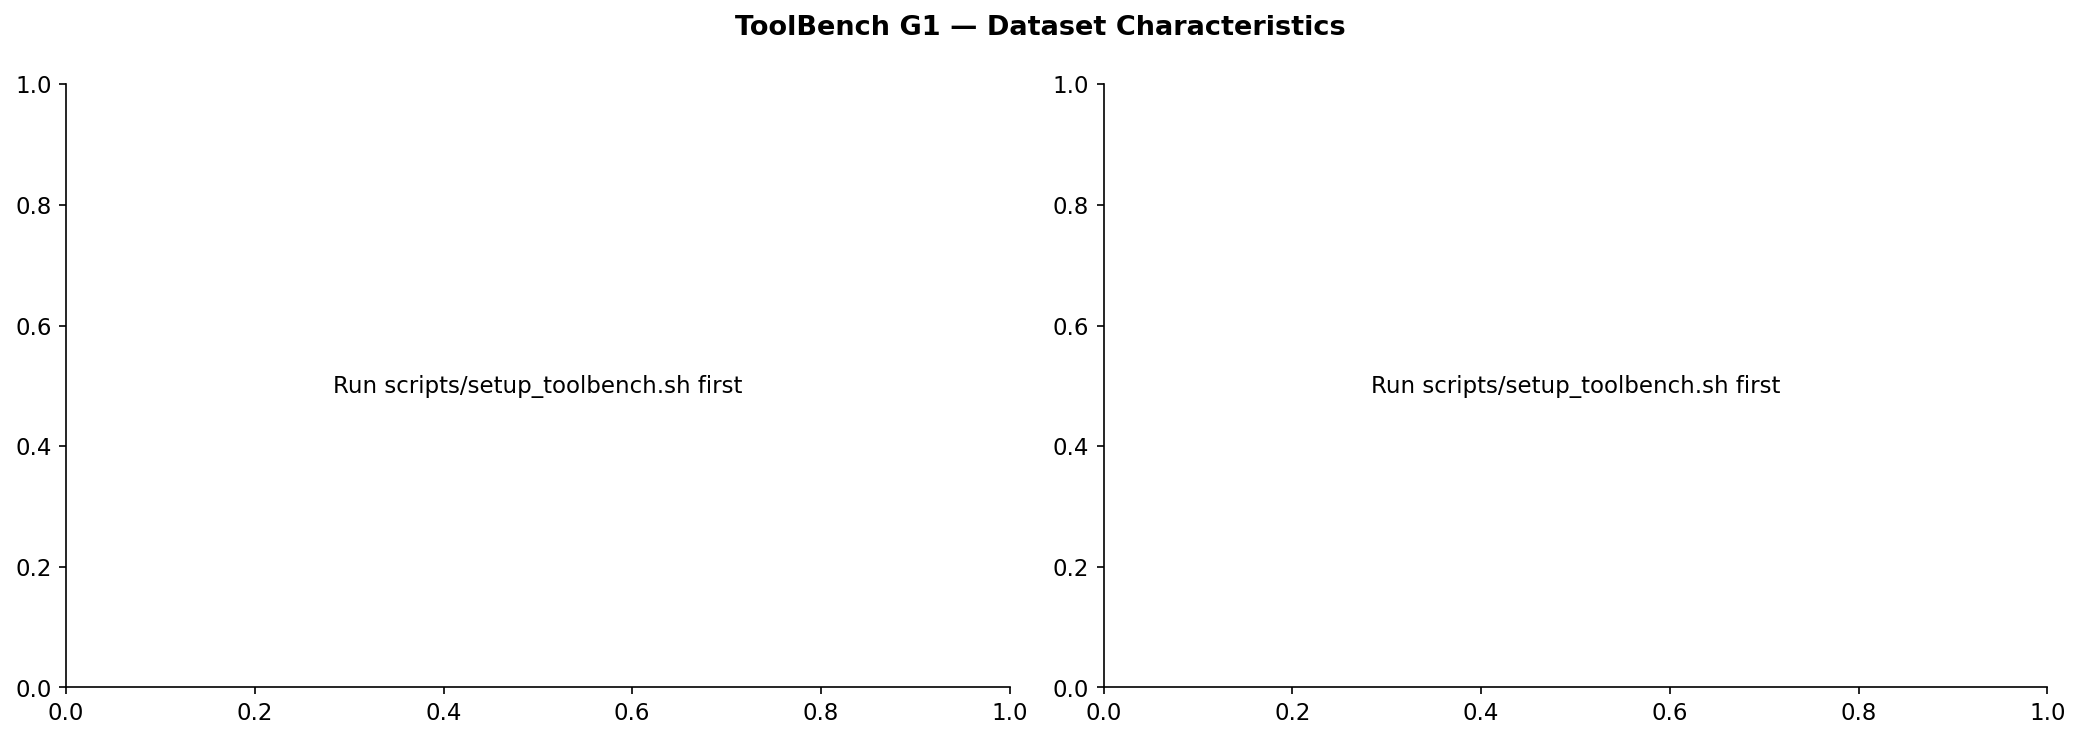

In [44]:
# ToolBench: query length + category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ToolBench G1 — Dataset Characteristics', fontsize=13, fontweight='bold')

path = DATA_DIR / 'toolbench_g1' / 'test.jsonl'
if path.exists():
    records = load_jsonl(path)
    stats_tb = load_stats('toolbench_g1')['splits']['test']

    # (a) Query length distribution
    q_lens = [r['metadata']['query_len'] for r in records]
    axes[0].hist(q_lens, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[0].set_xlabel('Query length (words)')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'(a) Query length (mean={np.mean(q_lens):.1f})')

    # (b) Top-15 API categories
    cats  = stats_tb['top_10_categories']
    names = list(cats.keys())[:10]
    vals  = [cats[n] for n in names]
    y_pos = np.arange(len(names))
    axes[1].barh(y_pos, vals, color='darkorange')
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([n[:35] for n in names], fontsize=9)
    axes[1].set_xlabel('Number of queries')
    axes[1].set_title('(b) Top-10 API categories')
    axes[1].invert_yaxis()
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'Run scripts/setup_toolbench.sh first',
                ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('../results/toolbench_dataset_analysis.png', bbox_inches='tight')
plt.show()

---
## 5  Cross-Benchmark Summary Table

For thesis Table 4.2 — Benchmarks and Tasks.

In [45]:
summary_path = DATA_DIR / 'summary.json'
if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    rows = summary['benchmarks']

    df = pd.DataFrame(rows)
    df = df[['benchmark', 'n_test', 'n_train', 'avg_instruction_len_words',
              'avg_reasoning_steps', 'avg_tool_calls', 'tool']]
    df.columns = ['Benchmark', 'N test', 'N train', 'Instr. (words)',
                  'Avg steps', 'Avg tool calls', 'Tool']
    df = df.fillna('—')
    print(df.to_string(index=False))
    print()

    # LaTeX version
    print('--- LaTeX ---')
    print(df.to_latex(index=False, escape=False,
                      column_format='llrrrrl',
                      float_format='{:.1f}'.format))
else:
    print('Run python scripts/prepare_datasets.py first.')

Benchmark  N test  N train  Instr. (words) Avg steps Avg tool calls                                       Tool
 hotpotqa    7405    90447       15.721404         —              — in-memory context search (search + lookup)

--- LaTeX ---
\begin{tabular}{llrrrrl}
\toprule
Benchmark & N test & N train & Instr. (words) & Avg steps & Avg tool calls & Tool \\
\midrule
hotpotqa & 7405 & 90447 & 15.7 & — & — & in-memory context search (search + lookup) \\
\bottomrule
\end{tabular}



---
## 6  Calibration / Test Split Planning

The thesis uses a 50/50 calibration/test split of each benchmark's sample set:
- **Calibration** (50%): fit normalisation parameters (q_98, u_min) for MSP-Answer/StepCoCoA;
  BranchConsistency uses a sigmoid transform of raw NLI logits and needs no calibration fit.
- **Test** (50%): held-out evaluation — all reported metrics are computed here.

This cell computes the actual sample sizes from `config.py`.

In [46]:
repo_root = REPO_ROOT if 'REPO_ROOT' in globals() else Path('..').resolve()
config_path = repo_root / 'config.py'

if not config_path.exists():
    raise FileNotFoundError(f'Could not find {config_path}')

local_config = SimpleNamespace(**runpy.run_path(config_path))
DEFAULT_CONFIG = local_config.DEFAULT_CONFIG
cfg = DEFAULT_CONFIG.experiment

splits = {
    'calib_frac': cfg.split_calib,
    'test_frac':  cfg.split_test,
}

EXPERIMENT_SIZES = {
    'gsm8k':         cfg.gsm8k_n,
    'agentbench_os': cfg.agentbench_os_n,
    'agentbench_db': cfg.agentbench_db_n,
    'toolbench_g1':  cfg.toolbench_g1_n,
    'hotpotqa':      cfg.hotpotqa_n,
}

# HotpotQA uses 50/50 split; others use the default calib_frac
HOTPOTQA_CALIB_FRAC = 0.5

print(f"{'Benchmark':<20} {'Total':>6} {'Calib':>10} {'Test':>8}  Note")
print('-' * 72)
for bname, n in EXPERIMENT_SIZES.items():
    frac   = HOTPOTQA_CALIB_FRAC if bname == 'hotpotqa' else splits['calib_frac']
    n_calib = int(n * frac)
    n_test  = n - n_calib
    note    = f'({frac:.0%}/{1-frac:.0%})' if bname == 'hotpotqa' else f'({frac:.0%}/{1-frac:.0%})'
    print(f"{bname:<20} {n:>6} {n_calib:>10} {n_test:>8}  {note}")

Benchmark             Total      Calib     Test  Note
------------------------------------------------------------------------
gsm8k                   500        250      250  (50%/50%)
agentbench_os            26         13       13  (50%/50%)
agentbench_db           360        180      180  (50%/50%)
toolbench_g1            300        150      150  (50%/50%)
hotpotqa                500        250      250  (50%/50%)


---
## 7  Difficulty Stratification (GSM8K)

Group GSM8K test problems by number of calculation steps to understand
how difficulty affects UQ performance — used in Section 5.3.

In [47]:
# Difficulty stratification with correct metric
bins = {
    'Easy (≤ 2)':   [r for r in gsm_test if r['metadata']['n_steps'] <= 2],
    'Medium (3–4)': [r for r in gsm_test if 3 <= r['metadata']['n_steps'] <= 4],
    'Hard (≥ 5)':   [r for r in gsm_test if r['metadata']['n_steps'] >= 5],
}

print(f"{'Difficulty':<20} {'Count':>7} {'Fraction':>10} {'Avg. steps':>12}")
print('-' * 52)
n_total = len(gsm_test)
for label, group in bins.items():
    avg_steps = np.mean([r['metadata']['n_steps'] for r in group])
    count = len(group)
    frac = count / n_total
    print(f"{label:<20} {count:>7} {frac:>10.1%} {avg_steps:>12.2f}")

Difficulty             Count   Fraction   Avg. steps
----------------------------------------------------
Easy (≤ 2)               326      24.7%         2.00
Medium (3–4)             668      50.6%         3.44
Hard (≥ 5)               325      24.6%         5.74
